In [1]:
# %%
# ============================================================
# COMPLETE RESULT ANALYSIS CODE
# For LightGCN + BPR experiments across datasets / layers / k
# ============================================================

import os
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
LOG_DIRS = {
    "movielens100k": "log/ml_100k/",
    "movielens1m": "log/ml_1m/",
    # "amazonBeauty2m": "log/beauty2m/",
}

SAVE_DIR = "figures/result_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

# Optional: dataset statistics for density / threshold analysis
# Fill these with your real values if available.
DATASET_STATS = {
    "movielens100k": {
        "n_users": 943,
        "n_items": 1682,
        "n_edges": 100000,
    },
    "movielens1m": {
        "n_users": 6040,
        "n_items": 3706,
        "n_edges": 1000209,
    },
    "amazonBeauty2m": {
        "n_users": 12101,   # replace if your processed set differs
        "n_items": 249274,  # replace if your processed set differs
        "n_edges": 2023070, # replace if your processed set differs
    },
}

# ------------------------------------------------------------
# HELPER: safe nested get
# ------------------------------------------------------------
def nested_get(d, keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

# ------------------------------------------------------------
# LOAD RESULTS
# ------------------------------------------------------------
def load_one_result(path):
    r = torch.load(path, map_location="cpu")

    config = r.get("config", {})
    timing = r.get("timing", {})
    test_result = r.get("test_result", {})
    memory = r.get("memory", {})

    dataset = config.get("dataset_name", "unknown_dataset")
    L = config.get("num_layers", None)
    k = config.get("num_samples_per_user", None)
    emb_dim = config.get("embedding_size", None)
    epochs = config.get("epochs", None)
    batch_size = config.get("batch_size", None)
    eval_batch_size = config.get("eval_batch_size", None)

    # Timing keys may vary slightly across files
    total_time = timing.get("total_training_time_seconds", np.nan)
    prop_time = timing.get("propagation_time_seconds", np.nan)

    # Try multiple possible names
    bpr_time = (
        timing.get("bpr_objective_time_seconds", None)
        if "bpr_objective_time_seconds" in timing else
        timing.get("score_loss_time_seconds", np.nan)
    )

    forward_time = (
        timing.get("forward_total_time_seconds", None)
        if "forward_total_time_seconds" in timing else
        timing.get("bpr_forward_total_time_seconds", np.nan)
    )

    backward_time = timing.get("backward_step_time_seconds", np.nan)
    eval_time = timing.get("evaluation_time_seconds", np.nan)
    avg_epoch_time = timing.get("average_epoch_time_seconds", np.nan)

    # Test metrics may also vary slightly
    test_p = (
        test_result.get("test_p", None)
        if "test_p" in test_result else
        nested_get(test_result, ["test_topks", "test_p"], np.nan)
    )
    test_r = (
        test_result.get("test_r", None)
        if "test_r" in test_result else
        nested_get(test_result, ["test_topks", "test_r"], np.nan)
    )

    test_bpr = test_result.get("BPR_loss", np.nan)
    test_reg = test_result.get("Reg_loss", np.nan)

    actual_mb = memory.get("actual_MB", {})
    theoretical_mb = memory.get("theoretical_MB", {})
    gpu_peak = memory.get("gpu_peak_MB", np.nan)

    row = {
        "file": os.path.basename(path),

        "dataset": dataset,
        "L": L,
        "k": k,
        "embedding_size": emb_dim,
        "epochs": epochs,
        "batch_size": batch_size,
        "eval_batch_size": eval_batch_size,

        "total_time": total_time,
        "prop_time": prop_time,
        "bpr_time": bpr_time,
        "forward_time": forward_time,
        "backward_time": backward_time,
        "eval_time": eval_time,
        "avg_epoch_time": avg_epoch_time,

        "precision": test_p,
        "recall": test_r,
        "test_bpr_loss": test_bpr,
        "test_reg_loss": test_reg,

        "gpu_peak_MB": gpu_peak,
        "R_all_csr_MB": actual_mb.get("R_all_csr", np.nan),
        "R_train_csr_MB": actual_mb.get("R_train_csr", np.nan),
        "split_train_MB": actual_mb.get("split_train", np.nan),
        "split_val_MB": actual_mb.get("split_val", np.nan),
        "split_test_MB": actual_mb.get("split_test", np.nan),
        "model_params_MB": actual_mb.get("model_params", np.nan),
        "norm_adj_gpu_MB": actual_mb.get("norm_adj_gpu", np.nan),

        "theoretical_total_MB": theoretical_mb.get("total_MB", np.nan),
        "theoretical_embeddings_MB": theoretical_mb.get("embeddings_MB", np.nan),
        "theoretical_adj_values_MB": theoretical_mb.get("adj_values_MB", np.nan),
        "theoretical_adj_indices_MB": theoretical_mb.get("adj_indices_MB", np.nan),
        "theoretical_propagation_MB": theoretical_mb.get("propagation_MB", np.nan),
        "theoretical_adam_MB": theoretical_mb.get("adam_moments_MB", np.nan),
        "theoretical_grad_MB": theoretical_mb.get("gradients_MB", np.nan),
    }

    # Derived actual total tracked memory
    row["actual_total_tracked_MB"] = np.nansum([
        row["R_all_csr_MB"],
        row["R_train_csr_MB"],
        row["split_train_MB"],
        row["split_val_MB"],
        row["split_test_MB"],
        row["model_params_MB"],
        row["norm_adj_gpu_MB"],
    ])

    return row


def load_results_from_dirs(log_dirs):
    rows = []

    for dataset_name, log_dir in log_dirs.items():
        if not os.path.exists(log_dir):
            print(f"[Warning] Log directory not found: {log_dir}")
            continue

        for f in os.listdir(log_dir):
            if f.endswith(".pkl"):
                path = os.path.join(log_dir, f)
                try:
                    row = load_one_result(path)
                    if row["dataset"] == "unknown_dataset":
                        row["dataset"] = dataset_name
                    rows.append(row)
                except Exception as e:
                    print(f"[Skip] Failed to load {path}: {e}")

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No experiment files were loaded.")

    df = df.sort_values(["dataset", "L", "k"]).reset_index(drop=True)

    # add dataset stats if available
    for stat_name in ["n_users", "n_items", "n_edges"]:
        df[stat_name] = df["dataset"].map(
            {d: DATASET_STATS.get(d, {}).get(stat_name, np.nan) for d in df["dataset"].unique()}
        )

    # graph density
    df["graph_density"] = df["n_edges"] / (df["n_users"] * df["n_items"])

    # average degree per user
    df["avg_user_degree"] = df["n_edges"] / df["n_users"]

    # time normalized by k
    df["time_per_k"] = df["total_time"] / df["k"]

    # performance efficiency
    df["recall_per_second"] = df["recall"] / df["total_time"]

    # memory ratio
    df["gpu_peak_per_k"] = df["gpu_peak_MB"] / df["k"]

    return df

In [11]:
# ------------------------------------------------------------
# THRESHOLD / DIMINISHING RETURN ANALYSIS
# ------------------------------------------------------------
def add_threshold_columns(df):
    out = df.copy()
    out = out.sort_values(["dataset", "L", "k"]).reset_index(drop=True)

    out["recall_diff"] = out.groupby(["dataset", "L"])["recall"].diff()
    out["precision_diff"] = out.groupby(["dataset", "L"])["precision"].diff()
    out["time_diff"] = out.groupby(["dataset", "L"])["total_time"].diff()

    # gain per added time
    out["recall_gain_per_sec"] = out["recall_diff"] / out["time_diff"]

    # relation to avg degree
    out["k_over_avg_degree"] = out["k"] / out["avg_user_degree"]

    return out


def find_thresholds(df, recall_diff_threshold=0.001, consecutive=2):
    """
    Find first k where marginal gain becomes small for 'consecutive' points.
    """
    results = []

    for (dataset, L), g in df.groupby(["dataset", "L"]):
        g = g.sort_values("k").reset_index(drop=True)

        found_k = None
        count = 0

        for i in range(len(g)):
            val = g.loc[i, "recall_diff"]
            if pd.notna(val) and val < recall_diff_threshold:
                count += 1
                if count >= consecutive:
                    found_k = g.loc[i - consecutive + 1, "k"]
                    break
            else:
                count = 0

        results.append({
            "dataset": dataset,
            "L": L,
            "threshold_k": found_k,
            "recall_diff_threshold": recall_diff_threshold,
            "consecutive_points": consecutive
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# SAVE PLOT HELPER
# ------------------------------------------------------------
def finalize_plot(title=None, xlabel=None, ylabel=None, save_name=None, rotate_xticks=False, show_legend=False):
    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

    if rotate_xticks:
        plt.xticks(rotation=45)

    if show_legend:
        plt.legend()

    plt.tight_layout()

    if save_name:
        plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()


# ------------------------------------------------------------
# PLOT FUNCTIONS
# ------------------------------------------------------------
def plot_metric_vs_k(df, metric, ylabel, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    plt.figure(figsize=(8, 5))
    for L in sorted(plot_df["L"].dropna().unique()):
        subset = plot_df[plot_df["L"] == L].sort_values("k")
        plt.plot(subset["k"], subset[metric], marker="o", label=f"L={L}")

    finalize_plot(
        title=f"{ylabel} vs Sampling Size" + (f" ({dataset})" if dataset else ""),
        xlabel="Sampling size per user (k)",
        ylabel=ylabel,
        show_legend=True,
        save_name=None, # f"{metric}_vs_k_{dataset if dataset else 'all'}.png"
    )


def plot_cross_dataset_metric_vs_k(df, metric, ylabel, L_value=1):
    plot_df = df[df["L"] == L_value].copy()

    plt.figure(figsize=(8, 5))
    for dataset in plot_df["dataset"].unique():
        subset = plot_df[plot_df["dataset"] == dataset].sort_values("k")
        plt.plot(subset["k"], subset[metric], marker="o", label=dataset)

    plt.legend()
    finalize_plot(
        title=f"{ylabel} vs Sampling Size Across Datasets (L={L_value})",
        xlabel="Sampling size per user (k)",
        ylabel=ylabel,
        show_legend=True,
        save_name=None # f"cross_dataset_{metric}_L{L_value}.png"
    )


def plot_runtime_breakdown_vs_k(df, dataset=None, L_value=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]
    if L_value is not None:
        plot_df = plot_df[plot_df["L"] == L_value]

    metrics = ["prop_time", "bpr_time", "backward_time", "eval_time"]

    plt.figure(figsize=(9, 5))
    for m in metrics:
        grouped = plot_df.groupby("k")[m].mean().sort_index()
        plt.plot(grouped.index, grouped.values, marker="o", label=m)

    plt.legend()
    finalize_plot(
        title=f"Runtime Breakdown vs k"
              + (f" ({dataset})" if dataset else "")
              + (f", L={L_value}" if L_value else ""),
        xlabel="Sampling size per user (k)",
        ylabel="Time (seconds)",
        show_legend=True,
        save_name=None, # f"runtime_breakdown_{dataset if dataset else 'all'}_L{L_value if L_value else 'all'}.png"
    )


def plot_prop_vs_bpr(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    plt.figure(figsize=(9, 5))
    for L in sorted(plot_df["L"].dropna().unique()):
        subset = plot_df[plot_df["L"] == L].sort_values("k")
        plt.plot(subset["k"], subset["prop_time"], marker="o", linestyle="--", label=f"Propagation L={L}")
        plt.plot(subset["k"], subset["bpr_time"], marker="s", linestyle="-", label=f"BPR/Score L={L}")

    plt.legend(ncol=2)
    finalize_plot(
        title="Propagation vs BPR/Score Time" + (f" ({dataset})" if dataset else ""),
        xlabel="Sampling size per user (k)",
        ylabel="Time (seconds)",
        show_legend=True,
        save_name=None # f"prop_vs_bpr_{dataset if dataset else 'all'}.png"
    )


def plot_efficiency_tradeoff(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    plt.figure(figsize=(8, 6))
    for L in sorted(plot_df["L"].dropna().unique()):
        subset = plot_df[plot_df["L"] == L]
        plt.scatter(subset["total_time"], subset["recall"], s=80, label=f"L={L}")

        for _, row in subset.iterrows():
            plt.annotate(
                f"k={int(row['k'])}",
                (row["total_time"], row["recall"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8
            )

    plt.legend()
    finalize_plot(
        title="Runtime vs Recall Trade-off" + (f" ({dataset})" if dataset else ""),
        xlabel="Total training time (seconds)",
        ylabel="Recall",
        show_legend=True,
        save_name=None # f"efficiency_tradeoff_{dataset if dataset else 'all'}.png"
    )


def plot_heatmap(df, metric, dataset):
    plot_df = df[df["dataset"] == dataset].copy()
    pivot = plot_df.pivot(index="L", columns="k", values=metric)

    plt.figure(figsize=(14, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    finalize_plot(
        title=f"{metric} Heatmap ({dataset})",
        xlabel="Sampling size per user (k)",
        ylabel="Layers (L)",
        show_legend=True,
        save_name=None # f"heatmap_{metric}_{dataset}.png"
    )


def plot_memory_vs_k(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    plt.figure(figsize=(8, 5))
    for L in sorted(plot_df["L"].dropna().unique()):
        subset = plot_df[plot_df["L"] == L].sort_values("k")
        plt.plot(subset["k"], subset["gpu_peak_MB"], marker="o", label=f"L={L}")

    plt.legend()
    finalize_plot(
        title="GPU Peak Memory vs Sampling Size" + (f" ({dataset})" if dataset else ""),
        xlabel="Sampling size per user (k)",
        ylabel="GPU peak memory (MB)",
        show_legend=True,
        save_name=None # f"gpu_peak_vs_k_{dataset if dataset else 'all'}.png"
    )


def plot_actual_memory_breakdown(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    mem_cols = [
        "R_all_csr_MB", "R_train_csr_MB", "split_train_MB", "split_val_MB", "split_test_MB",
        "model_params_MB", "norm_adj_gpu_MB"
    ]

    mean_vals = plot_df[mem_cols].mean()

    plt.figure(figsize=(9, 5))
    plt.bar(mean_vals.index, mean_vals.values)
    finalize_plot(
        title="Average Actual Memory Breakdown" + (f" ({dataset})" if dataset else ""),
        xlabel="Memory component",
        ylabel="Memory (MB)",
        show_legend=True,
        save_name=None, # f"actual_memory_breakdown_{dataset if dataset else 'all'}.png",
        rotate_xticks=True
    )


def plot_theoretical_memory_breakdown(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    mem_cols = [
        "theoretical_embeddings_MB", "theoretical_adj_values_MB", "theoretical_adj_indices_MB",
        "theoretical_propagation_MB", "theoretical_adam_MB", "theoretical_grad_MB"
    ]

    mean_vals = plot_df[mem_cols].mean()

    plt.figure(figsize=(9, 5))
    plt.bar(mean_vals.index, mean_vals.values)
    finalize_plot(
        title="Average Theoretical Memory Breakdown" + (f" ({dataset})" if dataset else ""),
        xlabel="Theoretical memory component",
        ylabel="Memory (MB)",
        show_legend=True,
        save_name=None, # f"theoretical_memory_breakdown_{dataset if dataset else 'all'}.png",
        rotate_xticks=True
    )


def plot_marginal_gain(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    plt.figure(figsize=(8, 5))
    for L in sorted(plot_df["L"].dropna().unique()):
        subset = plot_df[plot_df["L"] == L].sort_values("k")
        plt.plot(subset["k"], subset["recall_diff"], marker="o", label=f"L={L}")

    plt.axhline(0.001, linestyle="--", label="threshold = 0.001")
    plt.legend()
    finalize_plot(
        title="Marginal Recall Gain vs Sampling Size" + (f" ({dataset})" if dataset else ""),
        xlabel="Sampling size per user (k)",
        ylabel="Δ Recall",
        show_legend=True,
        save_name=None # f"marginal_gain_{dataset if dataset else 'all'}.png"
    )


def plot_recall_gain_per_sec(df, dataset=None):
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]

    plt.figure(figsize=(8, 5))
    for L in sorted(plot_df["L"].dropna().unique()):
        subset = plot_df[plot_df["L"] == L].sort_values("k")
        plt.plot(subset["k"], subset["recall_gain_per_sec"], marker="o", label=f"L={L}")

    plt.legend()
    finalize_plot(
        title="Recall Gain per Added Second vs k" + (f" ({dataset})" if dataset else ""),
        xlabel="Sampling size per user (k)",
        ylabel="Δ Recall / Δ Time",
        show_legend=True,
        save_name=None # f"recall_gain_per_sec_{dataset if dataset else 'all'}.png"
    )


def plot_k_over_degree(df):
    plot_df = df.copy()

    plt.figure(figsize=(8, 5))
    for dataset in plot_df["dataset"].unique():
        subset = plot_df[plot_df["dataset"] == dataset]
        grouped = subset.groupby("k")["k_over_avg_degree"].mean().sort_index()
        plt.plot(grouped.index, grouped.values, marker="o", label=dataset)

    plt.axhline(1.0, linestyle="--", label="k = avg degree")
    plt.legend()
    finalize_plot(
        title="k Relative to Average User Degree",
        xlabel="Sampling size per user (k)",
        ylabel="k / average user degree",
        show_legend=True,
        save_name=None # "k_over_avg_degree.png"
    )


def plot_threshold_vs_density(threshold_df, df):
    merged = threshold_df.merge(
        df[["dataset", "graph_density", "avg_user_degree"]].drop_duplicates(),
        on="dataset",
        how="left"
    )

    plt.figure(figsize=(8, 5))
    for L in sorted(merged["L"].dropna().unique()):
        subset = merged[merged["L"] == L]
        plt.scatter(subset["graph_density"], subset["threshold_k"], s=100, label=f"L={L}")

        for _, row in subset.iterrows():
            plt.annotate(
                row["dataset"],
                (row["graph_density"], row["threshold_k"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8
            )

    plt.legend()
    finalize_plot(
        title="Threshold k vs Graph Density",
        xlabel="Graph density",
        ylabel="Detected threshold k",
        show_legend=True,
        save_name=None # "threshold_vs_graph_density.png"
    )


def plot_threshold_vs_avg_degree(threshold_df, df):
    merged = threshold_df.merge(
        df[["dataset", "graph_density", "avg_user_degree"]].drop_duplicates(),
        on="dataset",
        how="left"
    )

    plt.figure(figsize=(8, 5))
    for L in sorted(merged["L"].dropna().unique()):
        subset = merged[merged["L"] == L]
        plt.scatter(subset["avg_user_degree"], subset["threshold_k"], s=100, label=f"L={L}")

        for _, row in subset.iterrows():
            plt.annotate(
                row["dataset"],
                (row["avg_user_degree"], row["threshold_k"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8
            )

    plt.legend()
    finalize_plot(
        title="Threshold k vs Average User Degree",
        xlabel="Average user degree",
        ylabel="Detected threshold k",
        show_legend=True,
        save_name=None # "threshold_vs_avg_degree.png"
    )


# ------------------------------------------------------------
# SUMMARY TABLES
# ------------------------------------------------------------
def build_best_performance_table(df):
    idx = df.groupby(["dataset", "L"])["recall"].idxmax()
    table = df.loc[idx, [
        "dataset", "L", "k", "recall", "precision", "total_time", "gpu_peak_MB"
    ]].sort_values(["dataset", "L"])
    return table.reset_index(drop=True)


def build_best_efficiency_table(df):
    idx = df.groupby(["dataset", "L"])["recall_per_second"].idxmax()
    table = df.loc[idx, [
        "dataset", "L", "k", "recall_per_second", "recall", "precision", "total_time"
    ]].sort_values(["dataset", "L"])
    return table.reset_index(drop=True)


def build_summary_by_dataset(df):
    summary = df.groupby("dataset").agg({
        "precision": ["max", "mean"],
        "recall": ["max", "mean"],
        "total_time": ["min", "max", "mean"],
        "gpu_peak_MB": ["min", "max", "mean"],
        "graph_density": "mean",
        "avg_user_degree": "mean",
    })
    return summary

In [4]:
# ------------------------------------------------------------
# MAIN EXECUTION
# ------------------------------------------------------------
df = load_results_from_dirs(LOG_DIRS)
df = add_threshold_columns(df)

print("\nLoaded experiment summary:")
print(df.head())

df.to_csv(os.path.join(SAVE_DIR, "all_experiment_results.csv"), index=False)

# threshold table
threshold_df = find_thresholds(df, recall_diff_threshold=0.001, consecutive=2)
threshold_df.to_csv(os.path.join(SAVE_DIR, "thresholds.csv"), index=False)

# best tables
best_perf = build_best_performance_table(df)
best_eff = build_best_efficiency_table(df)
summary_dataset = build_summary_by_dataset(df)

best_perf.to_csv(os.path.join(SAVE_DIR, "best_performance_table.csv"), index=False)
best_eff.to_csv(os.path.join(SAVE_DIR, "best_efficiency_table.csv"), index=False)
summary_dataset.to_csv(os.path.join(SAVE_DIR, "summary_by_dataset.csv"))

# print("\nBest performance table:")
# print(best_perf)

# print("\nBest efficiency table:")
# print(best_eff)

# print("\nThreshold table:")
# print(threshold_df)

# print("\nSummary by dataset:")
# print(summary_dataset)


Loaded experiment summary:
                                                file        dataset  L   k  \
0  result_movielens100k_1layers_1sample_allusers.pkl  movielens100k  1   1   
1  result_movielens100k_1layers_5sample_allusers.pkl  movielens100k  1   5   
2  result_movielens100k_1layers_10sample_allusers...  movielens100k  1  10   
3  result_movielens100k_1layers_15sample_allusers...  movielens100k  1  15   
4  result_movielens100k_1layers_20sample_allusers...  movielens100k  1  20   

   embedding_size  epochs  batch_size  eval_batch_size  total_time  prop_time  \
0              64      50        1024              512    7.821416   0.060506   
1              64      50        1024              512    9.223014   0.130883   
2              64      50        1024              512   13.425971   0.202231   
3              64      50        1024              512   16.674656   0.302601   
4              64      50        1024              512   22.810418   0.395331   

   ...  graph_de

In [10]:
# print("\nBest performance table:")
# print(best_perf)

# print("\nBest efficiency table:")
# print(best_eff)

# print("\nThreshold table:")
# print(threshold_df)

# print("\nSummary by dataset:")
# print(summary_dataset)

summary_dataset

precision              recall           total_time              \
                    max      mean       max      mean        min         max   
dataset                                                                        
movielens100k  0.229905  0.181495  0.157146  0.131468   6.110378   28.072066   
movielens1m    0.180215  0.178327  0.067979  0.067419  42.788311  333.278595   

                          gpu_peak_MB                         graph_density  \
                     mean         min         max        mean          mean   
dataset                                                                       
movielens100k   16.378184   25.498535   33.797363   28.338786      0.063047   
movielens1m    146.585457  142.351562  177.359375  153.348443      0.044684   

              avg_user_degree  
                         mean  
dataset                        
movielens100k      106.044539  
movielens1m        165.597517

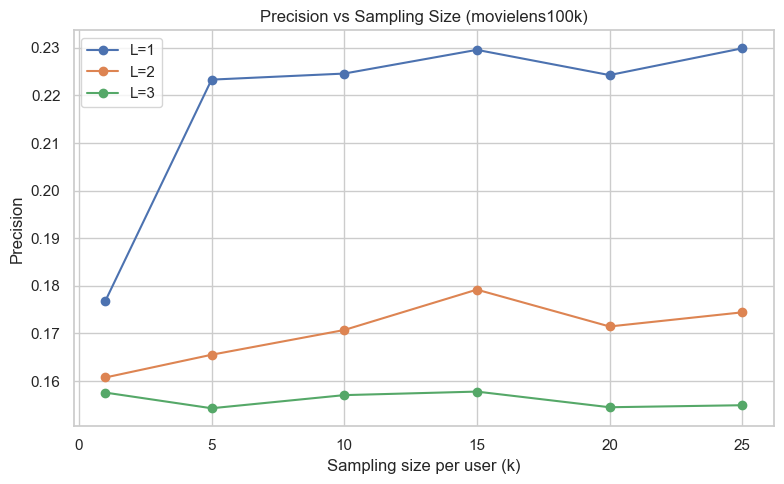

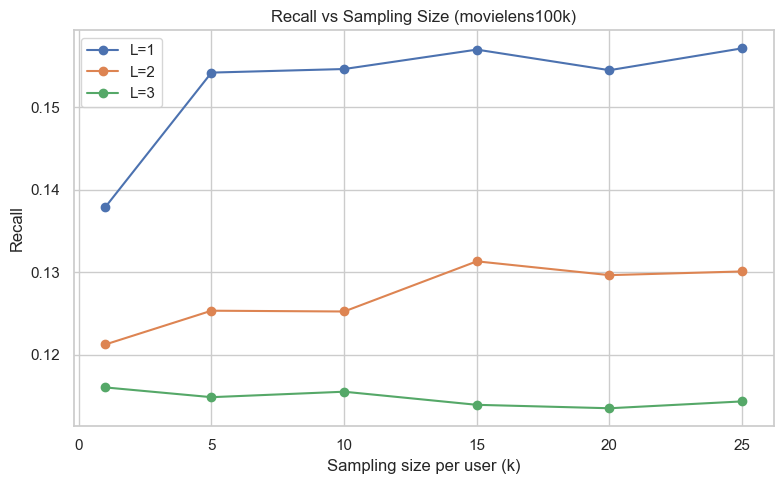

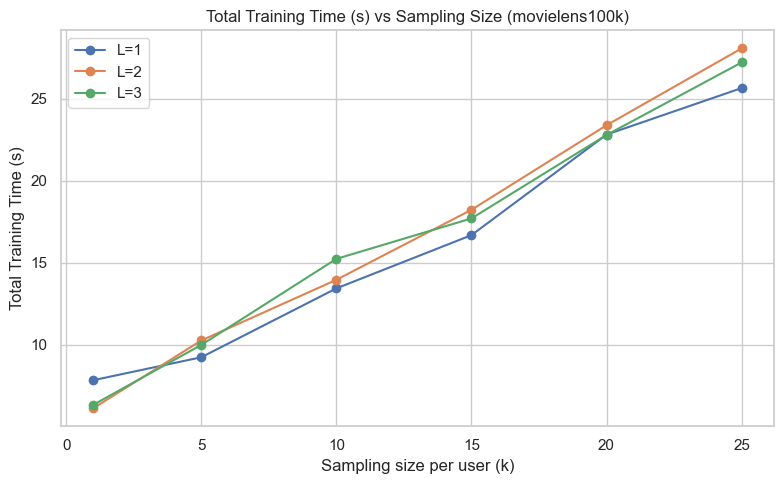

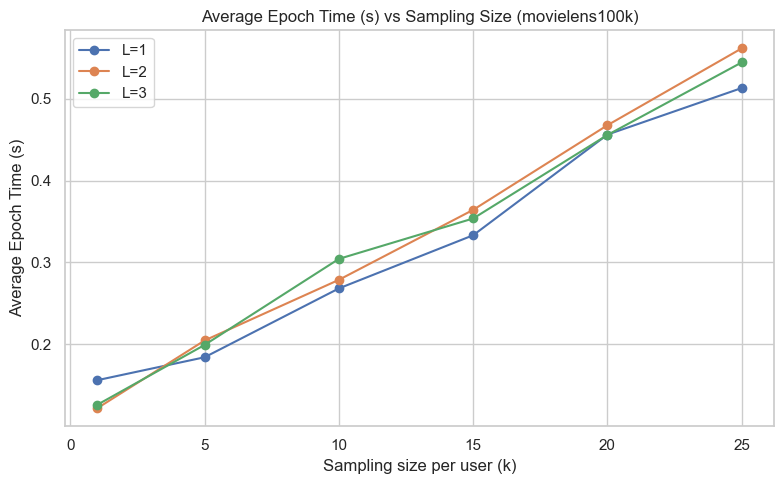

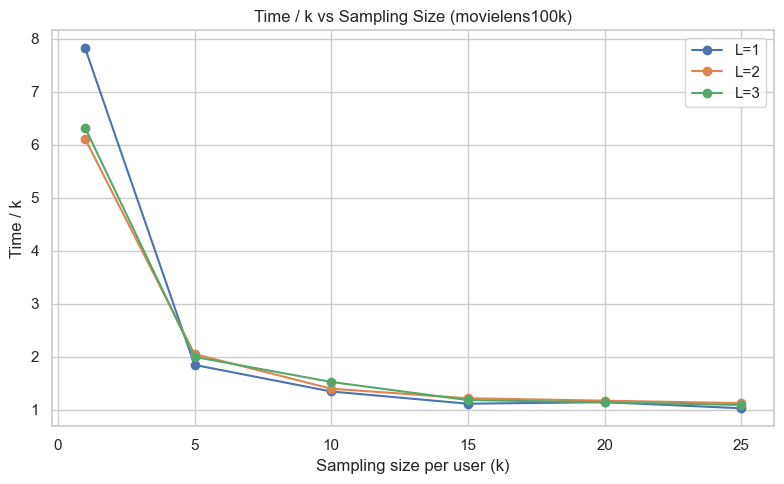

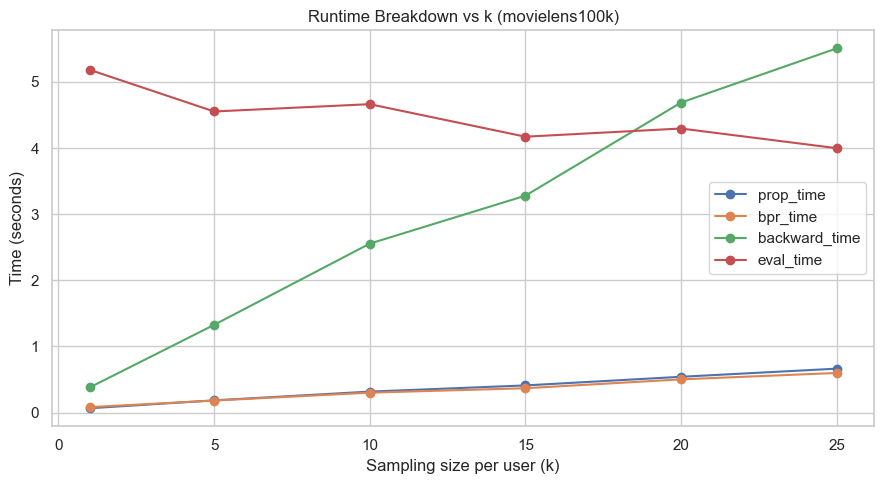

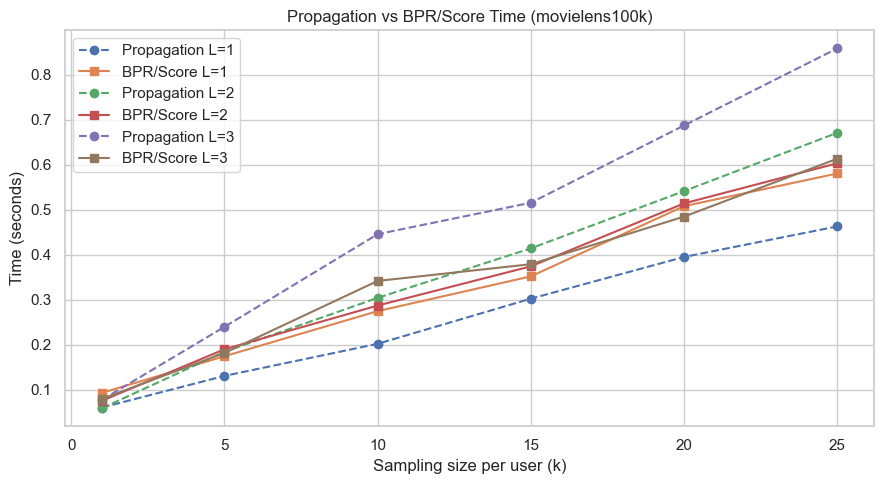

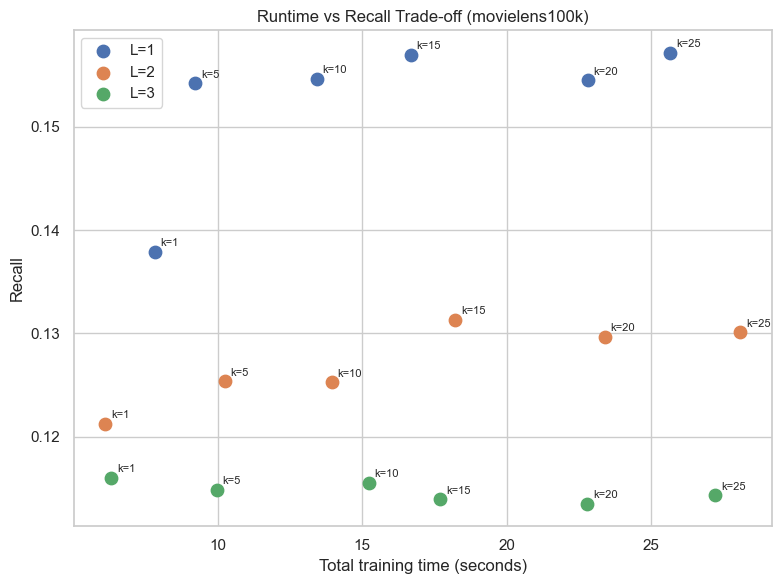

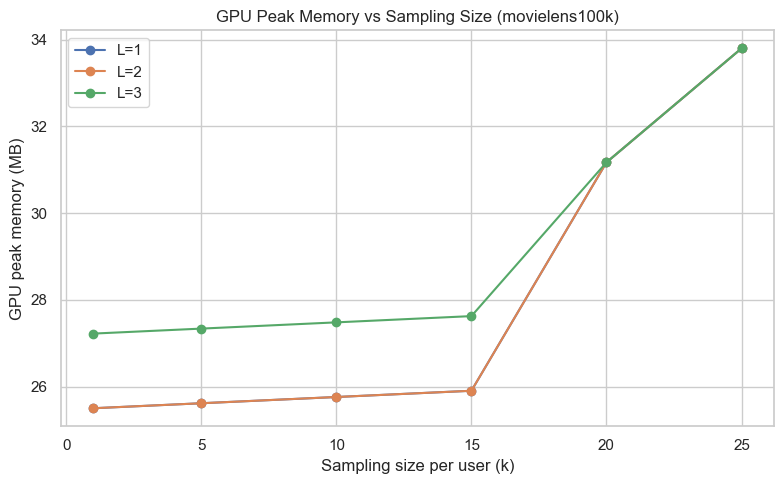

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


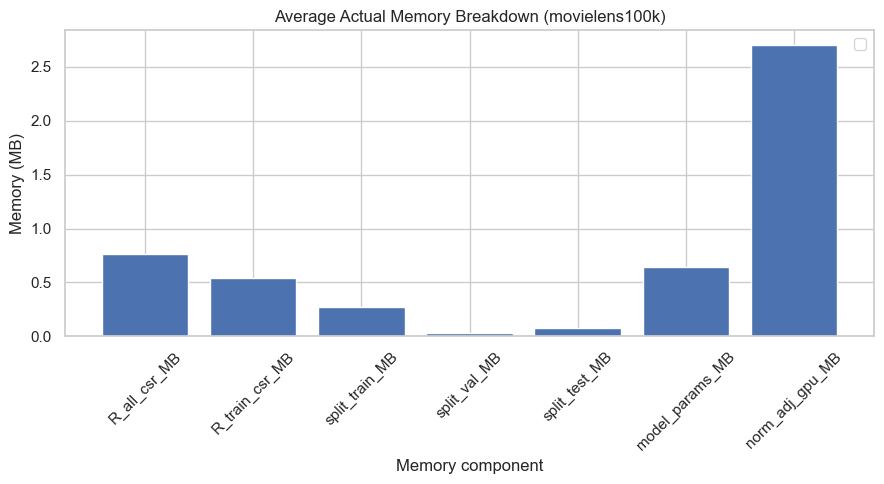

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


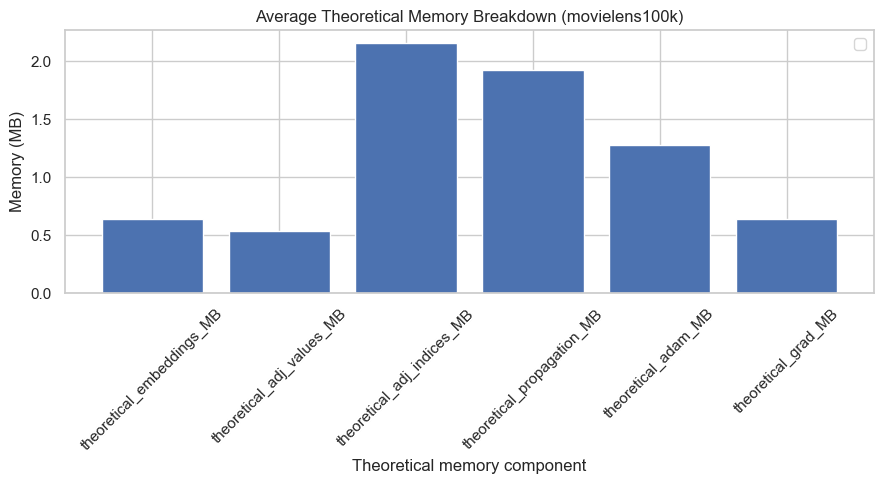

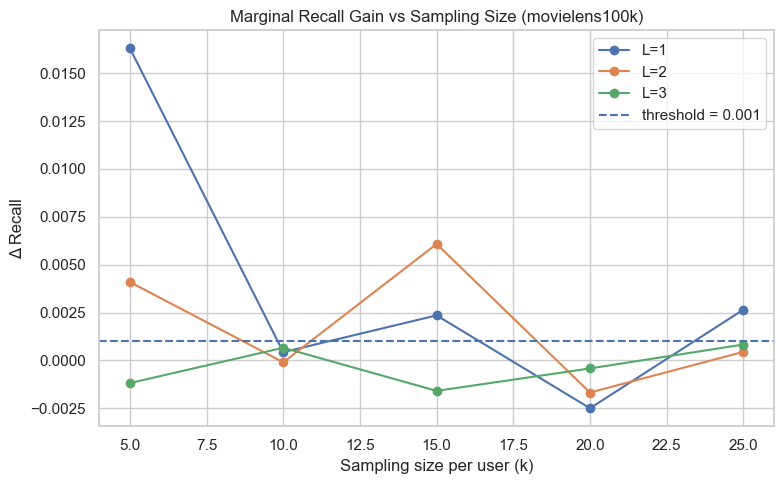

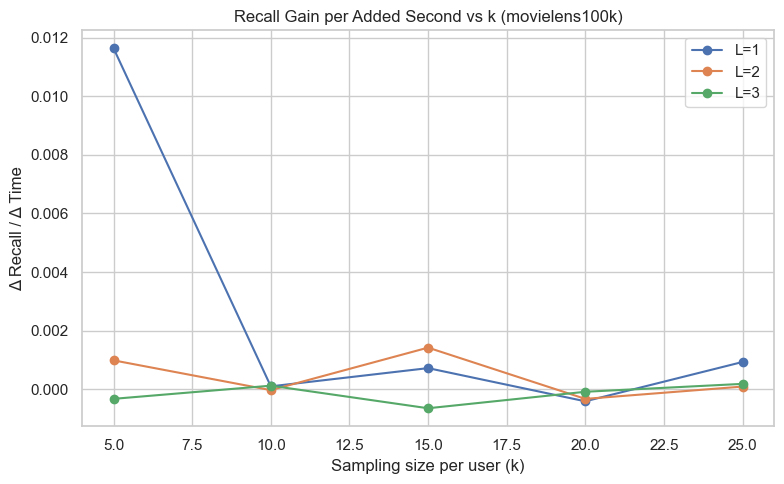

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


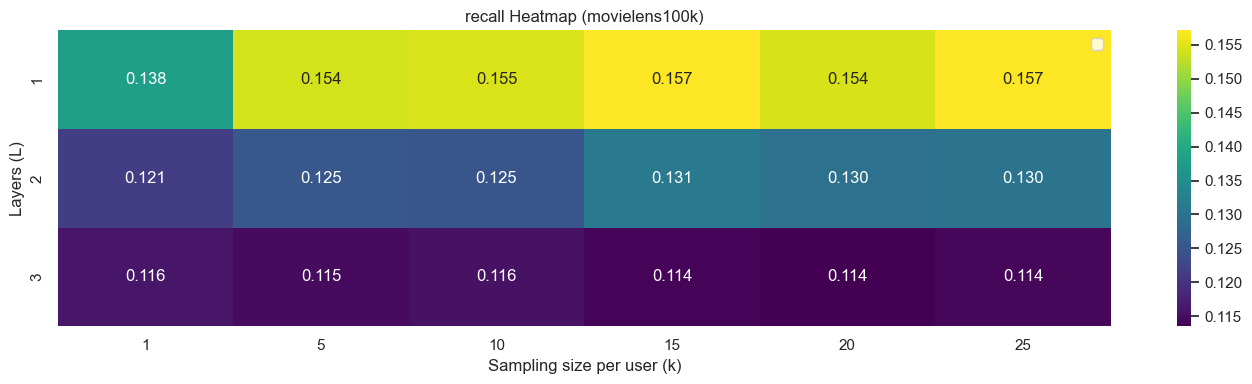

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


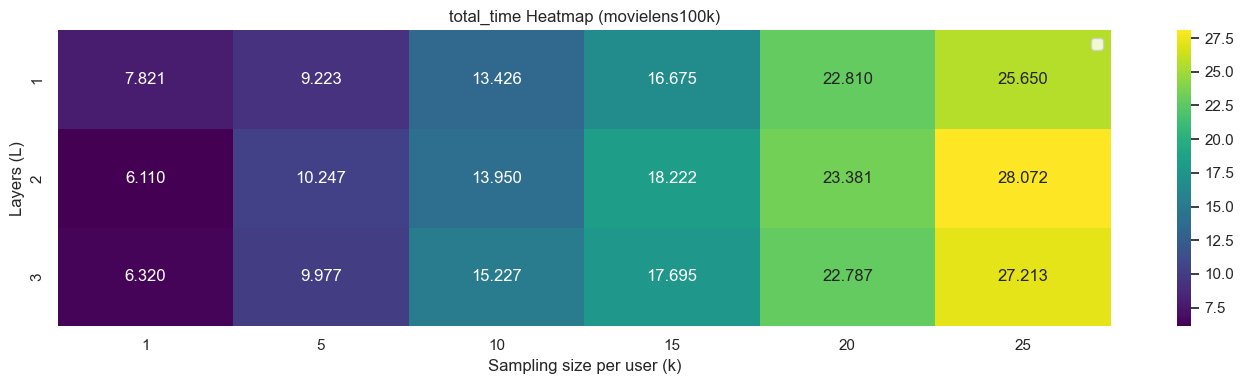

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


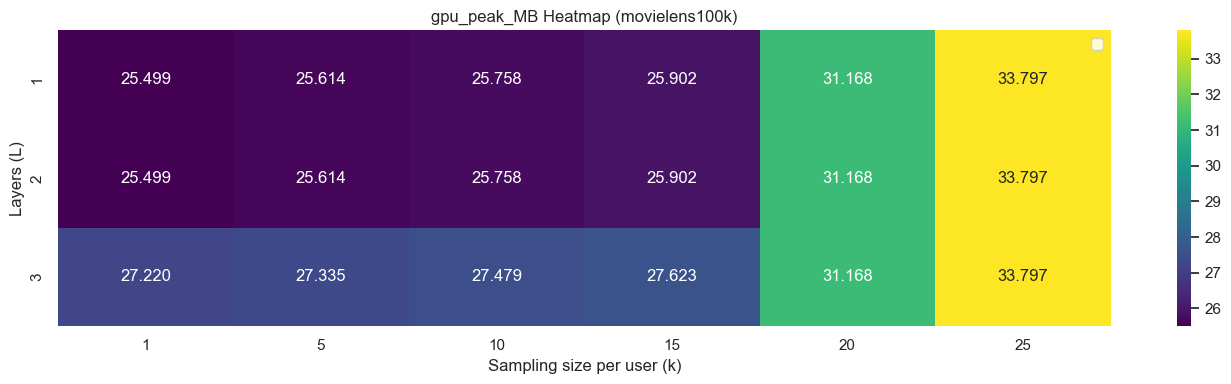

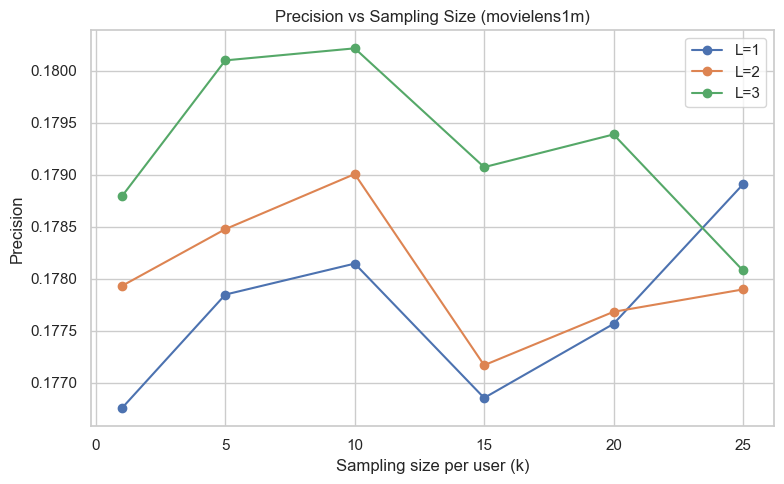

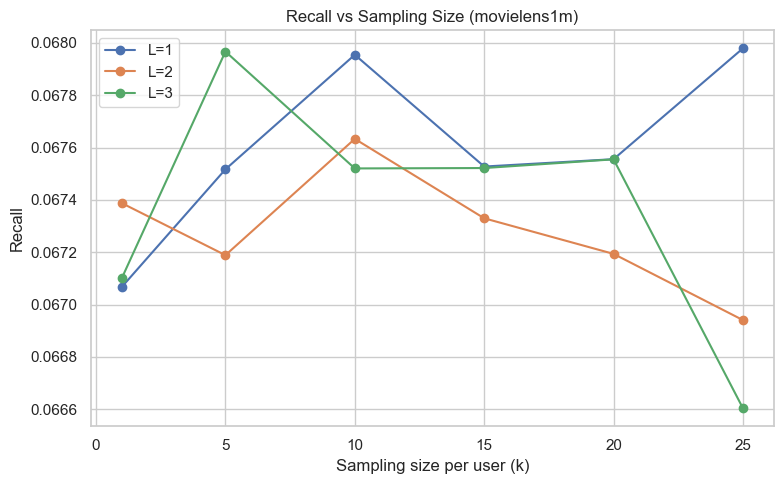

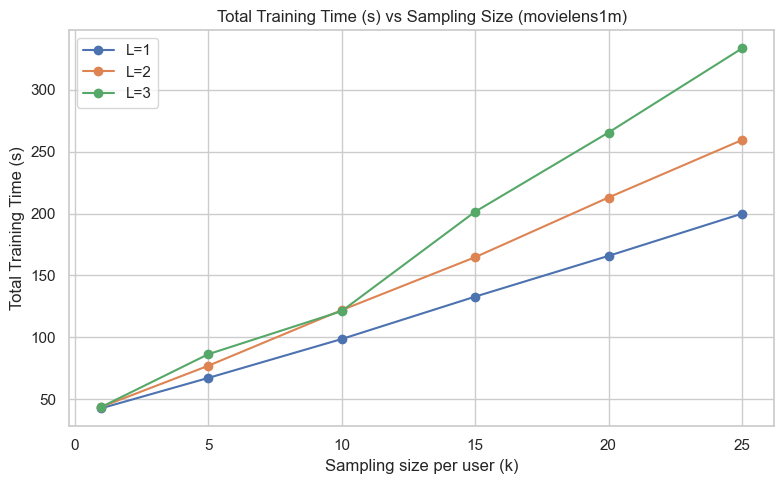

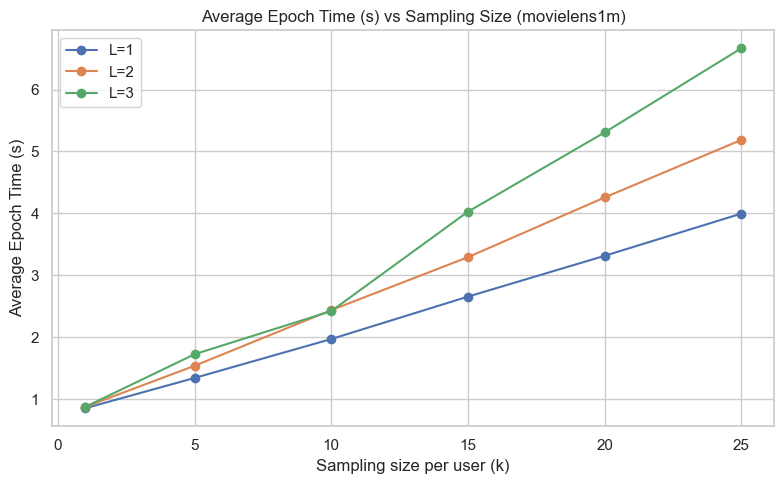

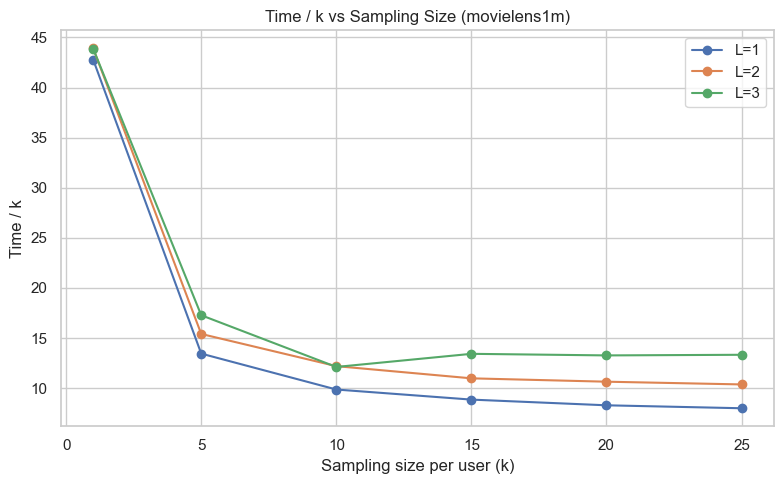

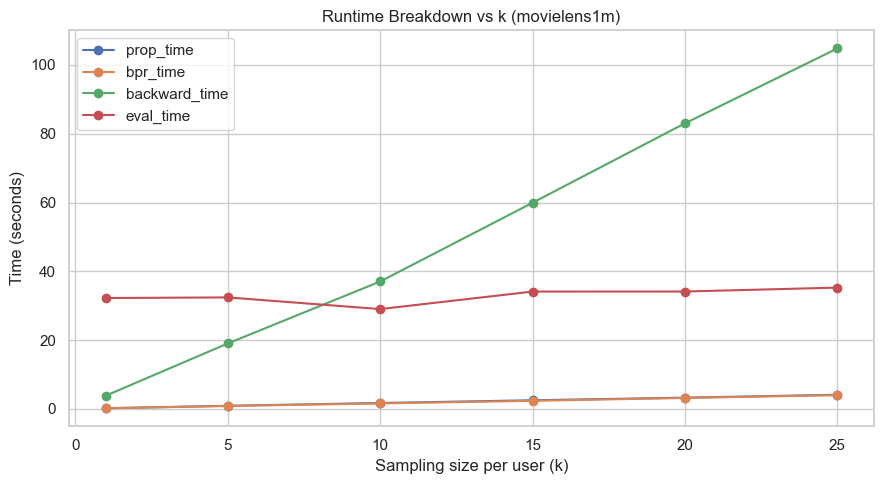

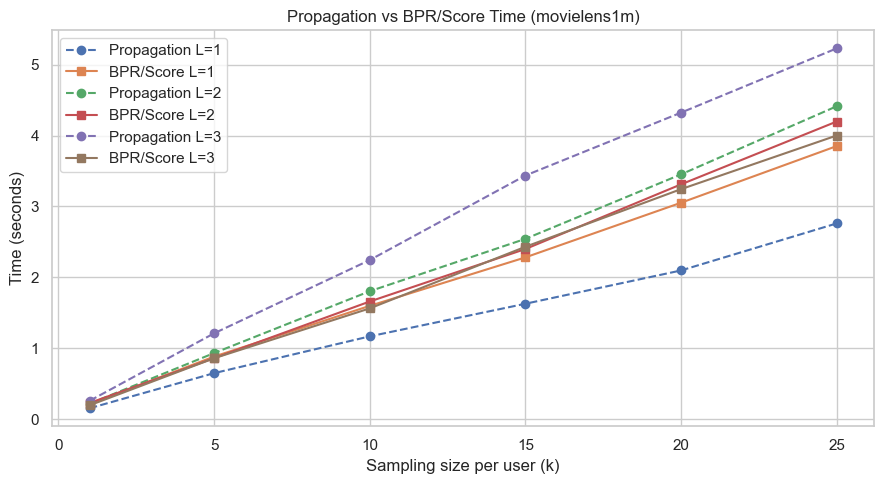

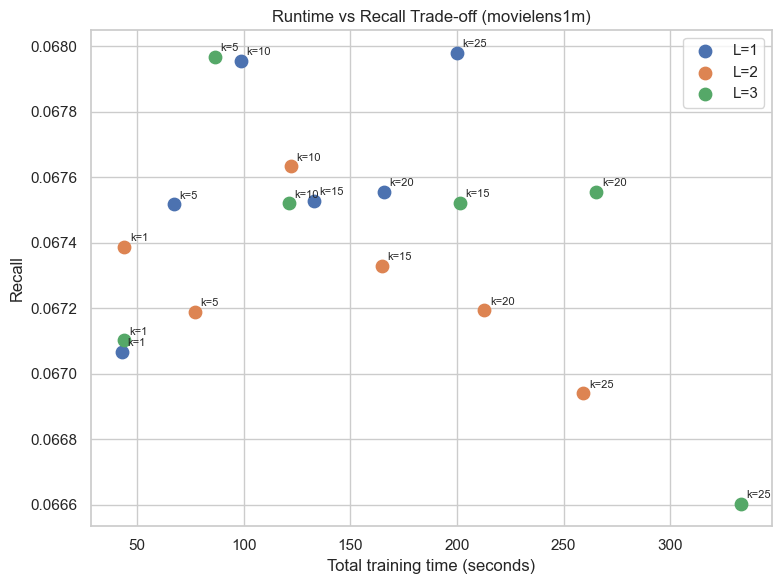

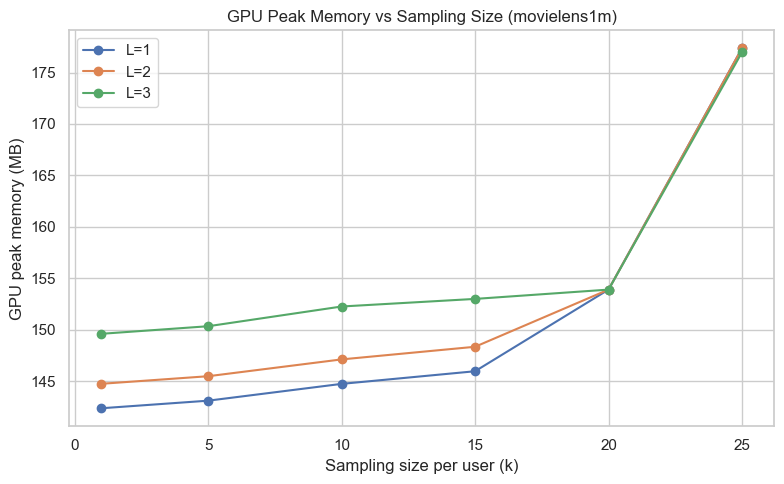

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


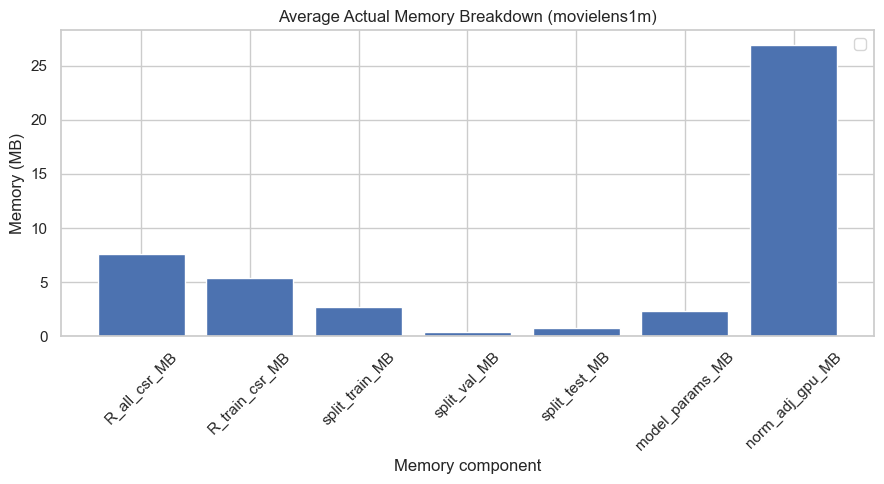

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


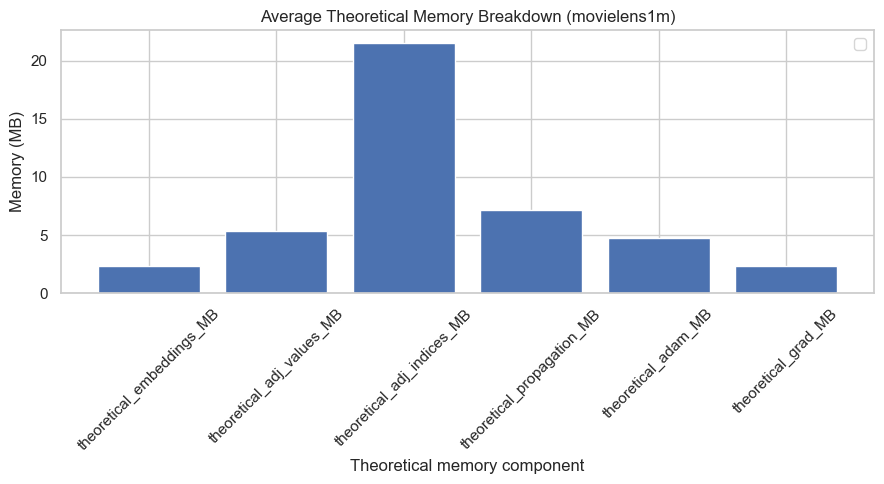

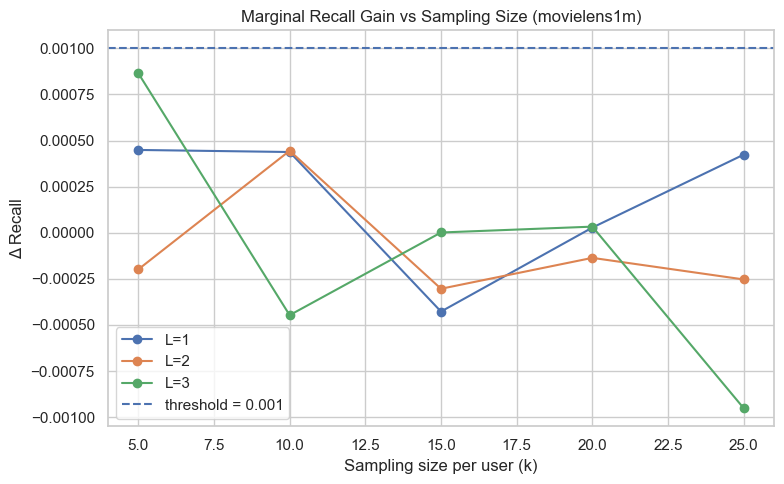

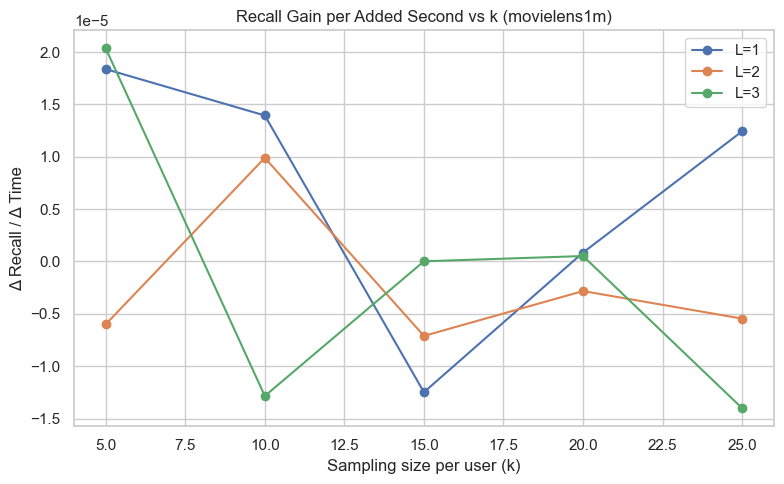

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


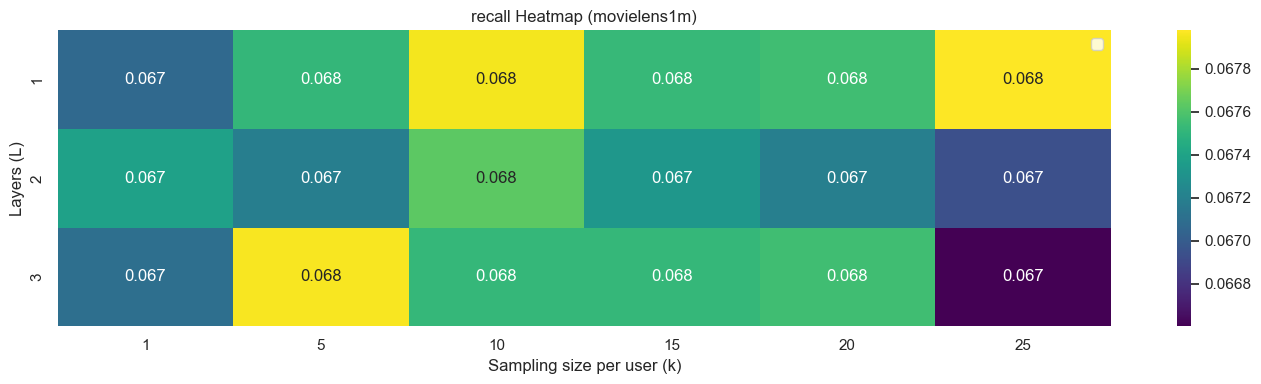

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


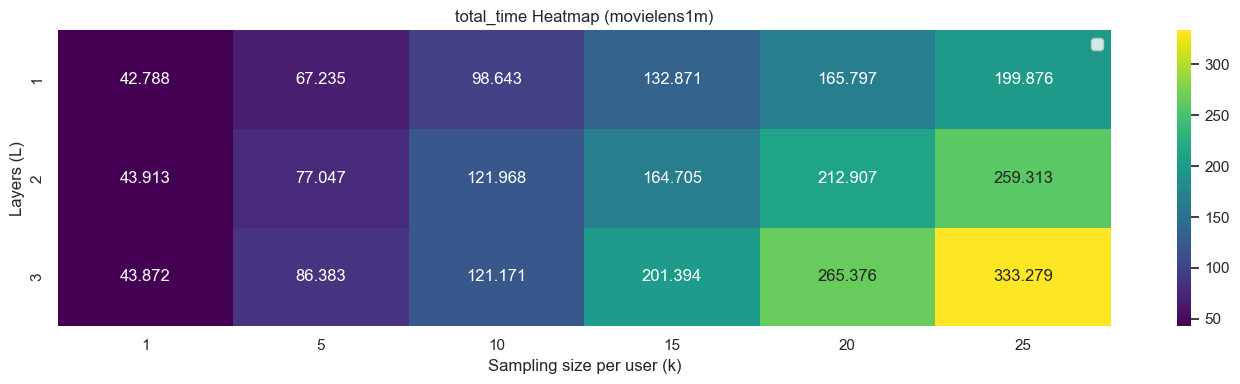

C:\Users\User\AppData\Local\Temp\ipykernel_5500\3981444947.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


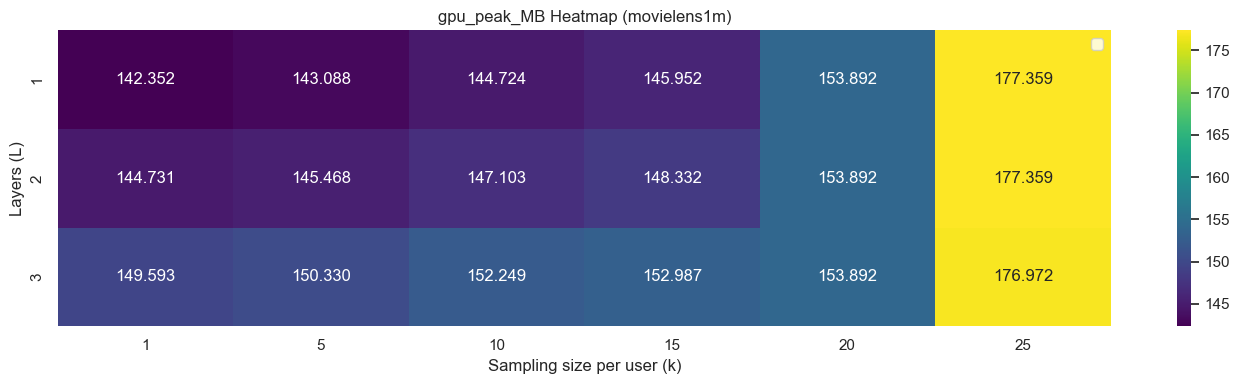

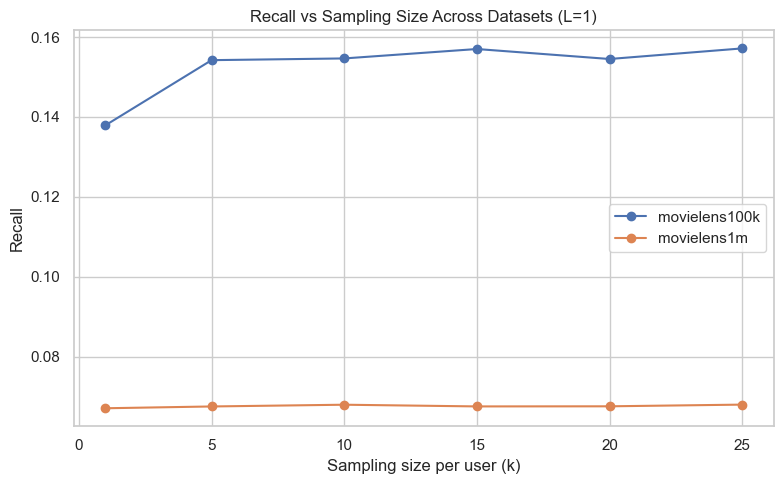

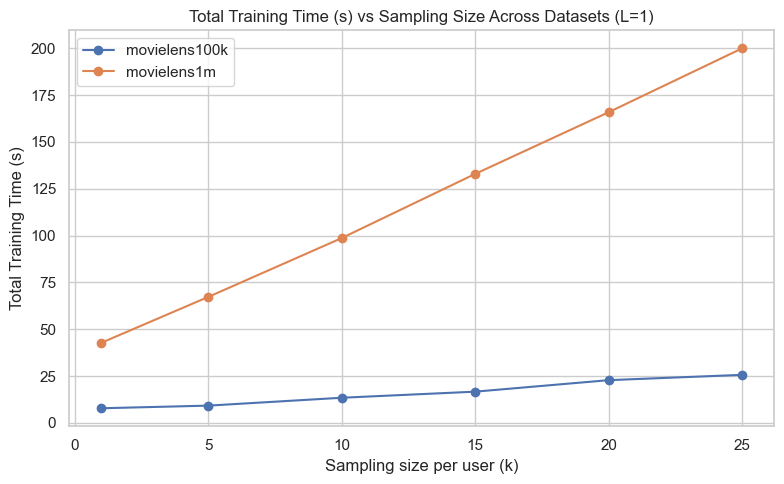

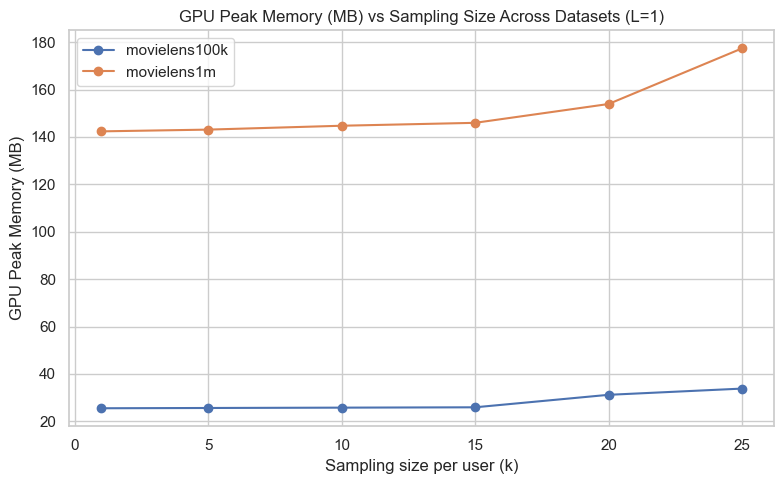

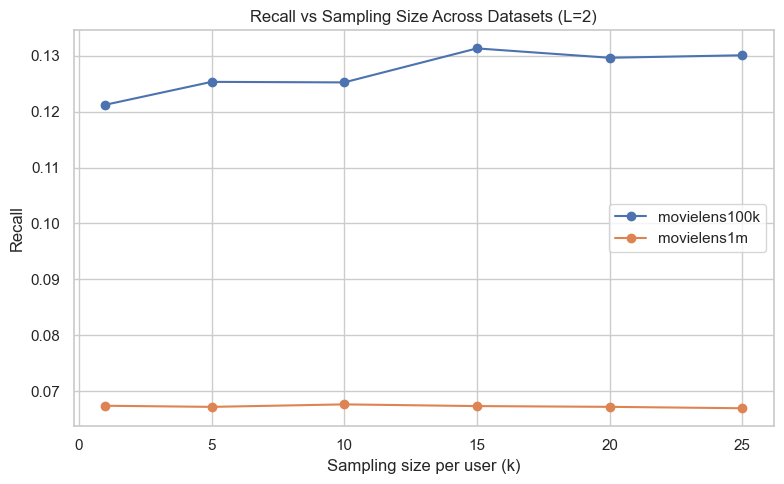

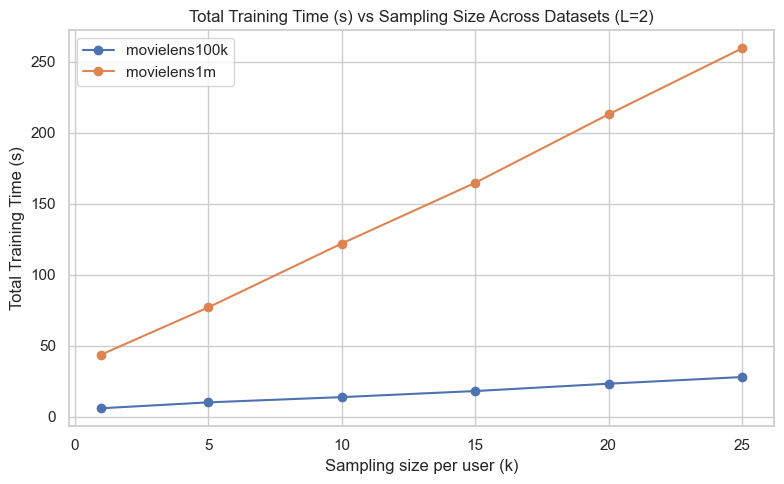

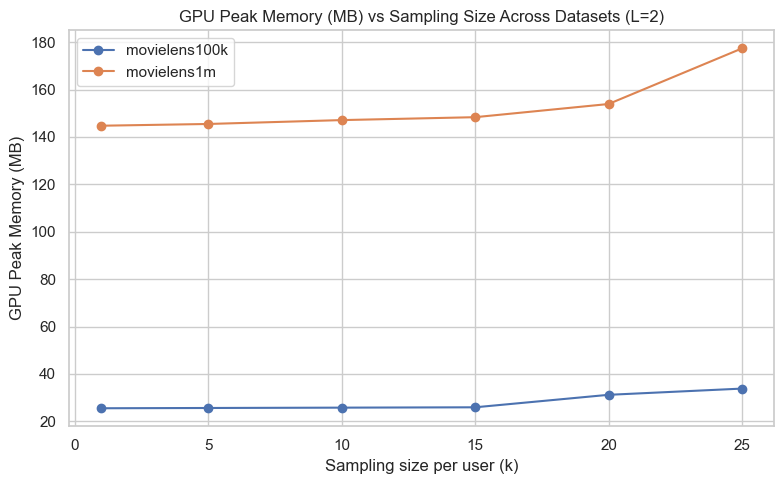

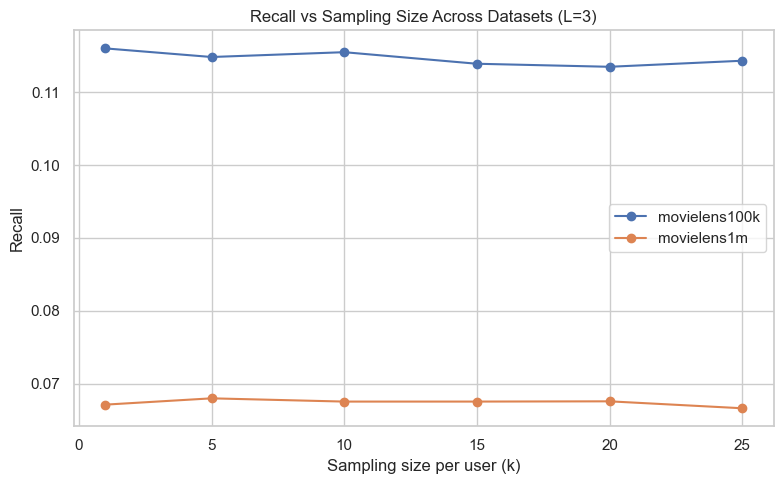

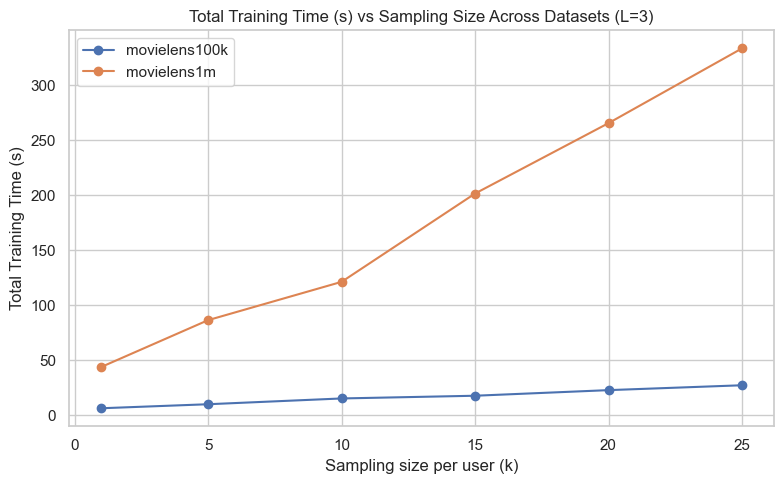

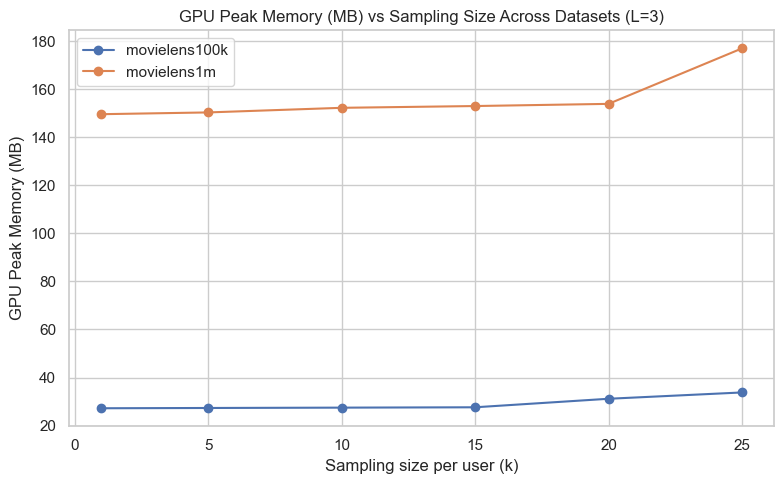

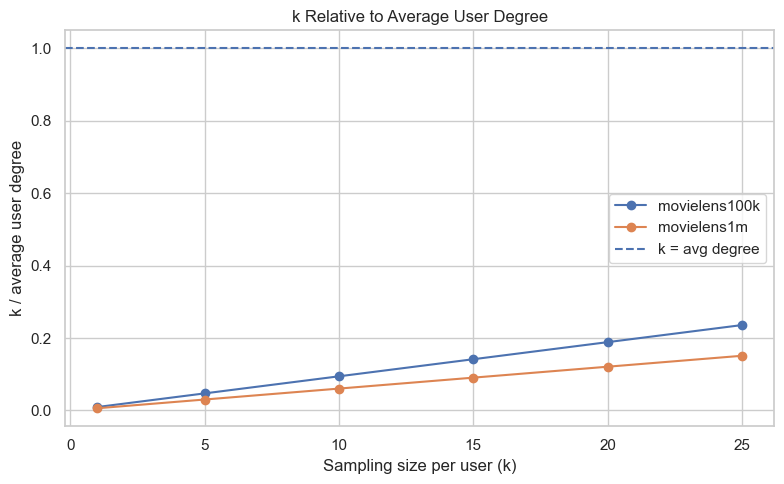

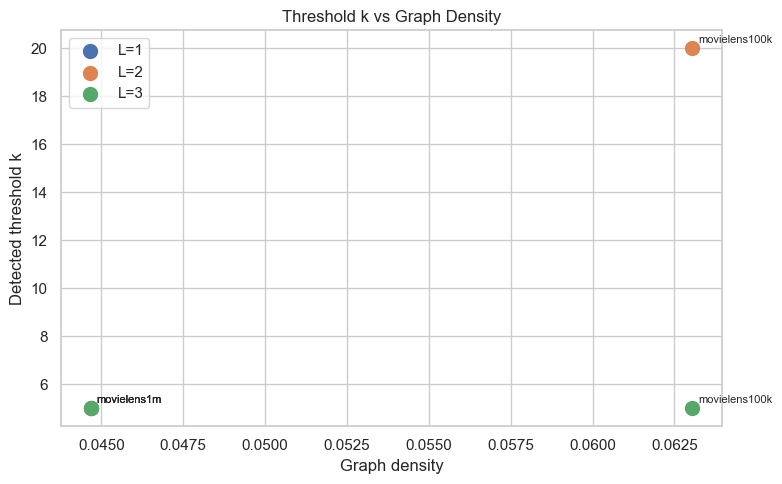

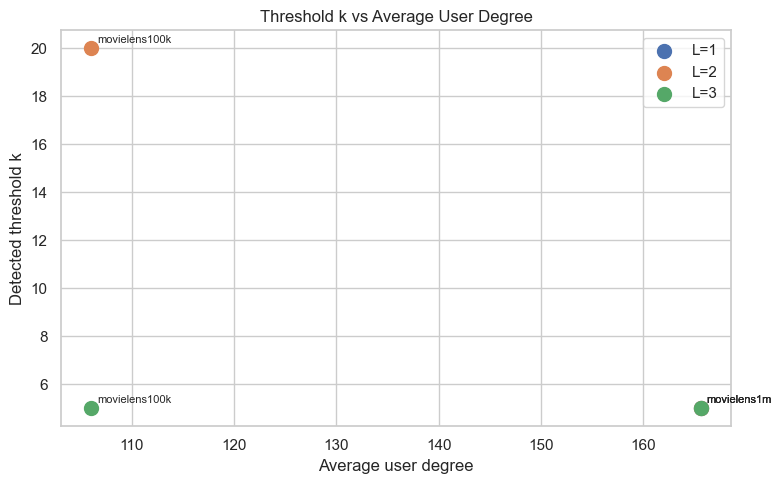


All outputs saved under: figures/result_analysis


In [12]:
# ------------------------------------------------------------
# PLOTS: per dataset
# ------------------------------------------------------------
for dataset in df["dataset"].unique():
    # performance
    plot_metric_vs_k(df, metric="precision", ylabel="Precision", dataset=dataset)
    plot_metric_vs_k(df, metric="recall", ylabel="Recall", dataset=dataset)

    # time complexity
    plot_metric_vs_k(df, metric="total_time", ylabel="Total Training Time (s)", dataset=dataset)
    plot_metric_vs_k(df, metric="avg_epoch_time", ylabel="Average Epoch Time (s)", dataset=dataset)
    plot_metric_vs_k(df, metric="time_per_k", ylabel="Time / k", dataset=dataset)
    plot_runtime_breakdown_vs_k(df, dataset=dataset)
    plot_prop_vs_bpr(df, dataset=dataset)

    # trade-off
    plot_efficiency_tradeoff(df, dataset=dataset)

    # memory
    plot_memory_vs_k(df, dataset=dataset)
    plot_actual_memory_breakdown(df, dataset=dataset)
    plot_theoretical_memory_breakdown(df, dataset=dataset)

    # threshold
    plot_marginal_gain(df, dataset=dataset)
    plot_recall_gain_per_sec(df, dataset=dataset)

    # heatmaps
    plot_heatmap(df, metric="recall", dataset=dataset)
    plot_heatmap(df, metric="total_time", dataset=dataset)
    plot_heatmap(df, metric="gpu_peak_MB", dataset=dataset)

# ------------------------------------------------------------
# PLOTS: cross dataset
# ------------------------------------------------------------
for L_value in sorted(df["L"].dropna().unique()):
    plot_cross_dataset_metric_vs_k(df, metric="recall", ylabel="Recall", L_value=L_value)
    plot_cross_dataset_metric_vs_k(df, metric="total_time", ylabel="Total Training Time (s)", L_value=L_value)
    plot_cross_dataset_metric_vs_k(df, metric="gpu_peak_MB", ylabel="GPU Peak Memory (MB)", L_value=L_value)

plot_k_over_degree(df)
plot_threshold_vs_density(threshold_df, df)
plot_threshold_vs_avg_degree(threshold_df, df)

# ------------------------------------------------------------
# OPTIONAL: ranking plots for selected dataset-layer
# ------------------------------------------------------------
def plot_selected_dataset_layer(df, dataset, L_value):
    subset = df[(df["dataset"] == dataset) & (df["L"] == L_value)].sort_values("k")

    plt.figure(figsize=(8, 5))
    plt.plot(subset["k"], subset["recall"], marker="o", label="Recall")
    plt.plot(subset["k"], subset["precision"], marker="s", label="Precision")
    plt.legend()
    finalize_plot(
        title=f"Performance vs k ({dataset}, L={L_value})",
        xlabel="Sampling size per user (k)",
        ylabel="Metric value",
        save_name=f"selected_perf_{dataset}_L{L_value}.png"
    )

    plt.figure(figsize=(8, 5))
    plt.plot(subset["k"], subset["total_time"], marker="o", label="Total time")
    plt.plot(subset["k"], subset["gpu_peak_MB"], marker="s", label="GPU peak MB")
    plt.legend()
    finalize_plot(
        title=f"Cost vs k ({dataset}, L={L_value})",
        xlabel="Sampling size per user (k)",
        ylabel="Cost",
        save_name=f"selected_cost_{dataset}_L{L_value}.png"
    )

# Example:
# plot_selected_dataset_layer(df, "movielens100k", 1)

print(f"\nAll outputs saved under: {SAVE_DIR}")